In [1]:
%cd ../

/Users/paulb/Desktop/code/research/babi


In [2]:
import os
import pandas as pd
import numpy as np
import data.constants
from data import plotting
import models.constants
from models import processing, constants
import matplotlib.pyplot as plt

import importlib
importlib.reload(data.constants)
importlib.reload(models.constants)
importlib.reload(plotting)
importlib.reload(processing)

<module 'models.processing' from '/Users/paulb/Desktop/code/research/babi/models/processing.py'>

Constraint 'min_amplitude' failures: 92044
Constraint 'plateau_slope_tolerance' failures: 122982
Constraint 'plateau_vertical_tolerance' failures: 3377
Constraint 'min_length' failures: 8640
Constraint 'max_units_from_zero' failures: 478
Constraint 'unit_max_amplitude' failures: 4825
Constraint 'mean_max_amplitude_error_percentage' failures: 33
Min unit length: 0.55 seconds.
Max unit length: 1.50 seconds.
Mean unit length: 1.12 seconds.
Total unit length: 33.34 minutes.
Extracted 1778 units for training dataset.
After pruning, 1620 units remain for training dataset.
Training dataset shape: (1296, 20, 1), Validation dataset shape: (324, 20, 1)


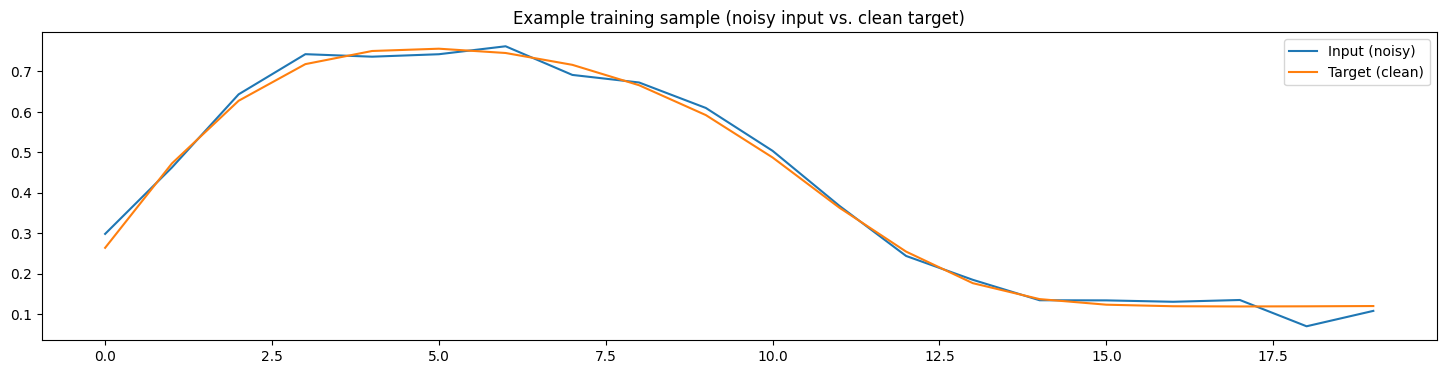

In [3]:
(train_x, train_y), val, (g_min, g_max) = processing.get_training_dataset(with_pruning=True)
print(f"Training dataset shape: {train_x.shape}, Validation dataset shape: {val.shape}")

plotting.dual(train_x[0], train_y[0], title="Example training sample (noisy input vs. clean target)", l1="Input (noisy)", l2="Target (clean)")

In [4]:
from models import autoencoder

ae = autoencoder.build()

history = ae.fit(
    train_x, train_y,
    validation_data=(val, val),
    epochs=100,
    batch_size=32,
    shuffle=True
)

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1663 - val_loss: 0.0294
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0234 - val_loss: 0.0161
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0160 - val_loss: 0.0146
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0151 - val_loss: 0.0140
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0146 - val_loss: 0.0138
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0141 - val_loss: 0.0135
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0138 - val_loss: 0.0134
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0135 - val_loss: 0.0131
Epoch 9/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0133 - val_loss: 0.0130
Epoch 10/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0130 - val_loss: 0.0126
Epoch 11/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0127 - val_loss: 0.0124
Epoch 12/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0

In [6]:
sample_path = os.listdir(os.path.join(data.constants.preprocessed_data_dir, "capnostream"))[1]
sample: pd.DataFrame = pd.read_pickle(os.path.join(data.constants.preprocessed_data_dir, "capnostream", sample_path))
print(sample.attrs)
signal = processing.scale_sample(sample["co2_wave"].to_numpy(), g_min, g_max)

{'Patient ID': 'BB_003_1', 'Patient Type': 'Infant/Neonatal', 'Report Generation Time': 'Mar 10,25  08:12:56 AM', 'Date': 'Mar 10,25'}


In [7]:
from models.processing import augmentation
from numpy.lib.stride_tricks import sliding_window_view

units = sliding_window_view(signal, (constants.unit_length, ))
units = np.array([augmentation.stretch_to_unit_length(unit)[0] for unit in units])

In [28]:
threshold = autoencoder.calculate_threshold(ae, val, percentile=95)
print(f"Calculated threshold: {threshold}")
predict = autoencoder.predictor(ae, threshold)
batch_predict = autoencoder.batch_predictor(ae, threshold)

Calculated threshold: 0.007041898752688059


In [29]:
from itertools import compress

recons, errors, labels = batch_predict(units)
predictions: list[tuple[np.ndarray, np.ndarray, np.floating, np.bool]] = list(zip(units, recons, errors, labels))
valid_predictions = list(compress(predictions, labels))
invalid_predictions = list(compress(predictions, ~labels))

print(f"Total units: {len(predictions)}")
print(f"Valid units: {len(valid_predictions)} ({round(len(valid_predictions) / len(predictions) * 100, 2)}%)")
print(f"Invalid units: {len(invalid_predictions)} ({round(len(invalid_predictions) / len(predictions) * 100, 2)}%)")

Total units: 40386
Valid units: 3302 (8.18%)
Invalid units: 37084 (91.82%)



----- VALID SAMPLES -----

(20,) (20,) 0.004487078654777622 True
Valid Sample 1 (Index 536) | 0.004487 (-0.002555)


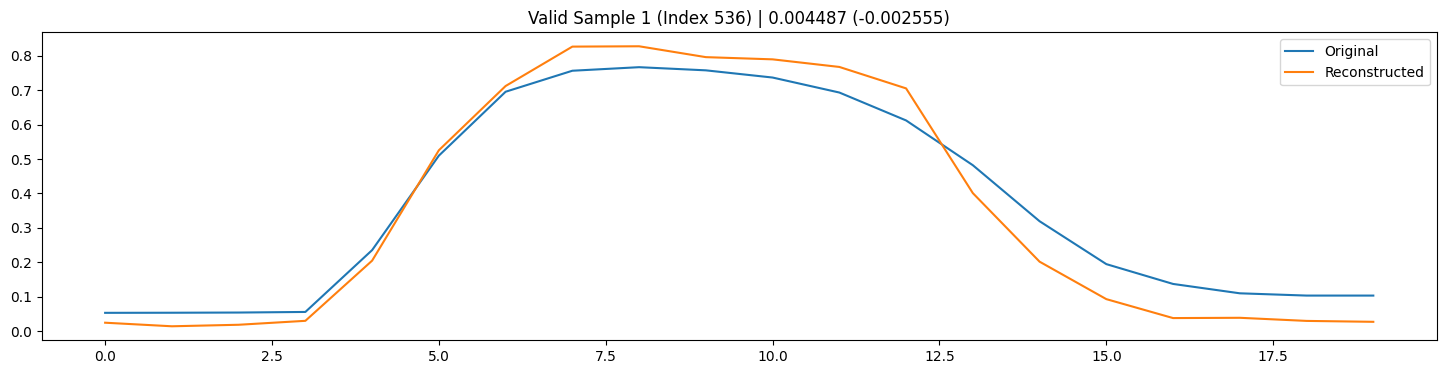

(20,) (20,) 0.006712855079655622 True
Valid Sample 2 (Index 1218) | 0.006713 (-0.000329)


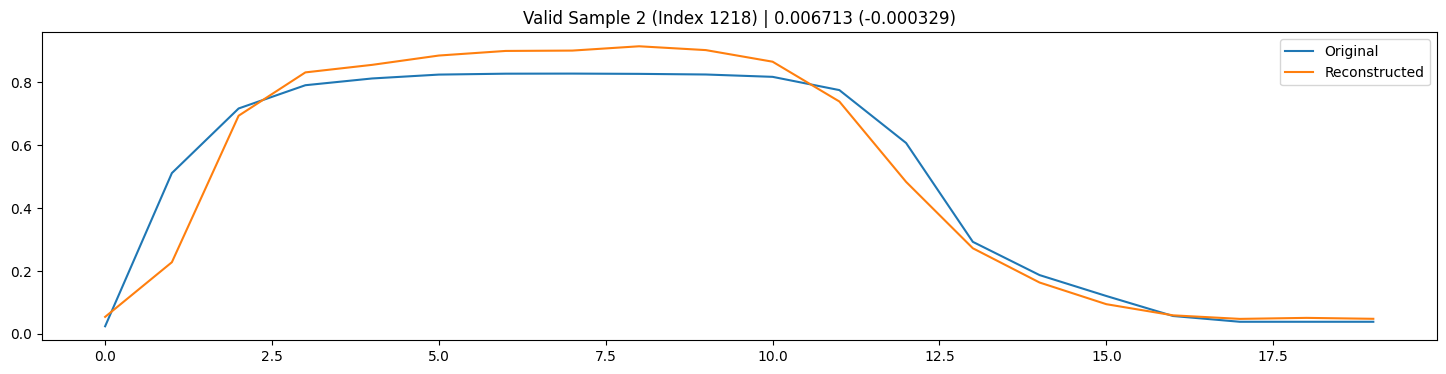

(20,) (20,) 0.0023550083500627444 True
Valid Sample 3 (Index 985) | 0.002355 (-0.004687)


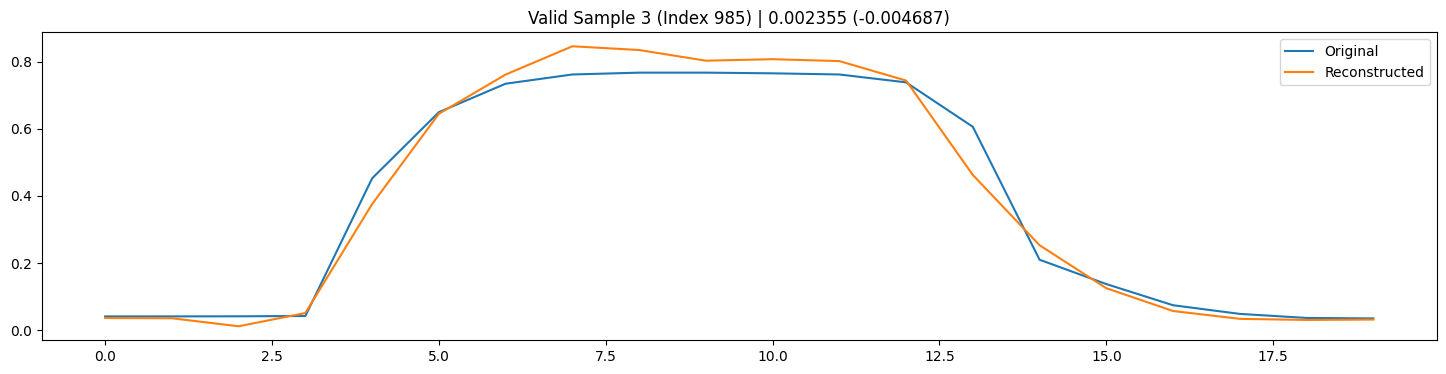


-----INVALID SAMPLES -----

Invalid Sample 1 (Index 6677) | 0.014095 (0.007053)


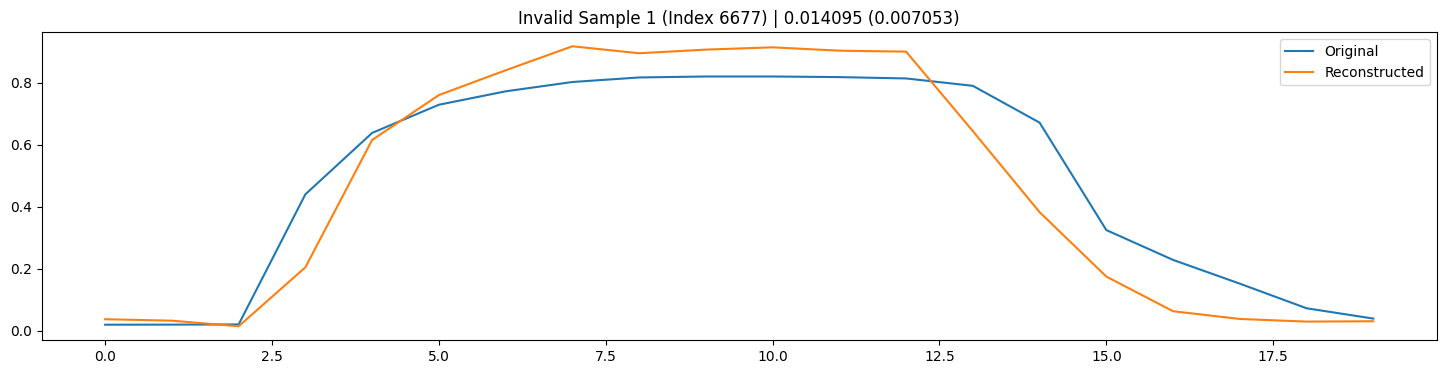

Invalid Sample 2 (Index 20357) | 0.065813 (0.058771)


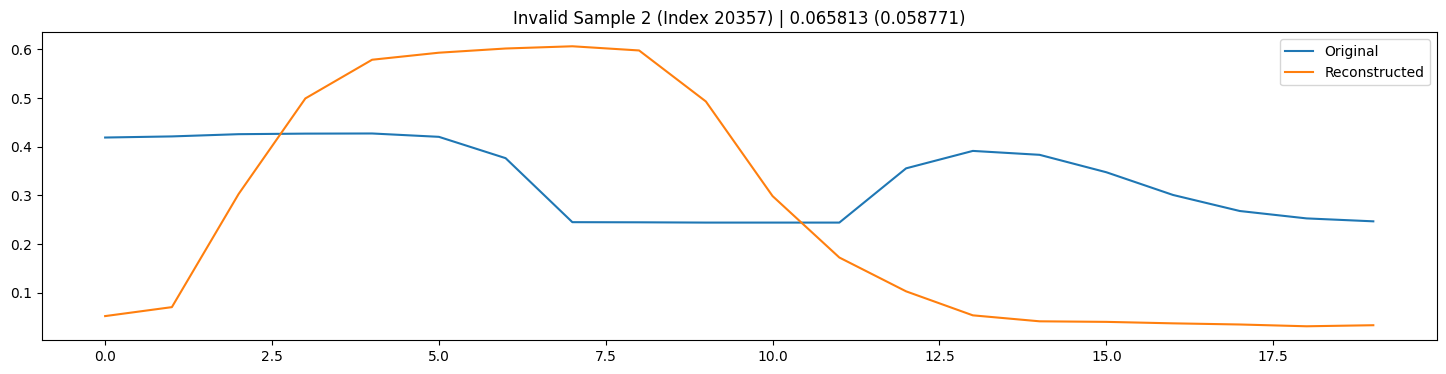

Invalid Sample 3 (Index 23474) | 0.035949 (0.028907)


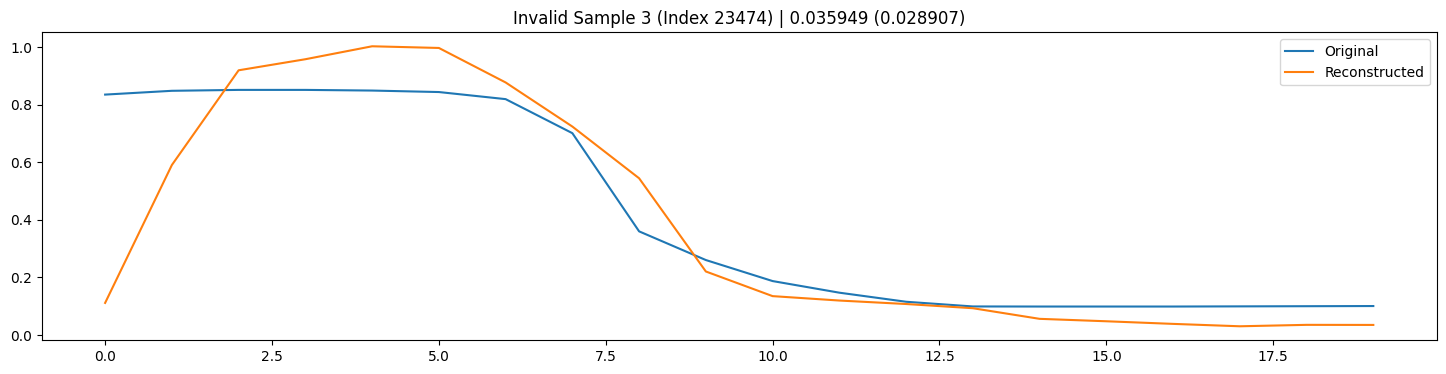

In [34]:
print("\n----- VALID SAMPLES -----\n")

n_valid_predictions = 3
for i in range(n_valid_predictions):
    index = np.random.randint(0, len(valid_predictions))
    original, recon, error, valid = valid_predictions[index]
    print(original.shape, recon.shape, error, valid)
    title = f'Valid Sample {i+1} (Index {index}) | {round(error, 6)} ({round(error - threshold, 6)})'
    print(title)
    plotting.dual(original, recon, title=title)

print("\n-----INVALID SAMPLES -----\n")

n_invalid_predictions = 3
for i in range(n_invalid_predictions):
    index = np.random.randint(0, len(invalid_predictions))
    original, recon, error, valid = invalid_predictions[index]
    title = f'Invalid Sample {i+1} (Index {index}) | {round(error, 6)} ({round(error - threshold, 6)})'
    print(title)
    plotting.dual(original, recon, title=title)

----- BEST VALID SAMPLES -----

Valid Sample 1 | 0.000353 (-0.006688)


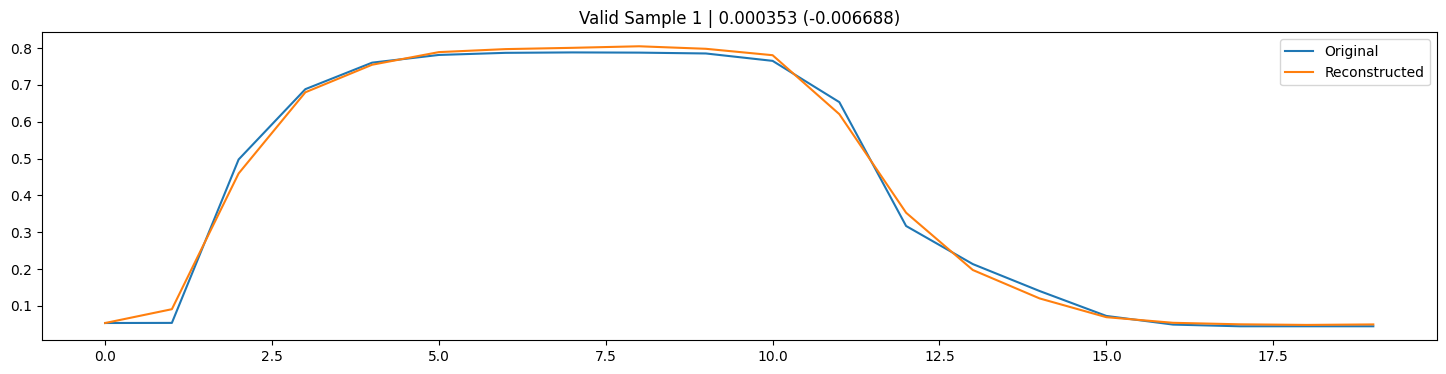

Valid Sample 2 | 0.000374 (-0.006668)


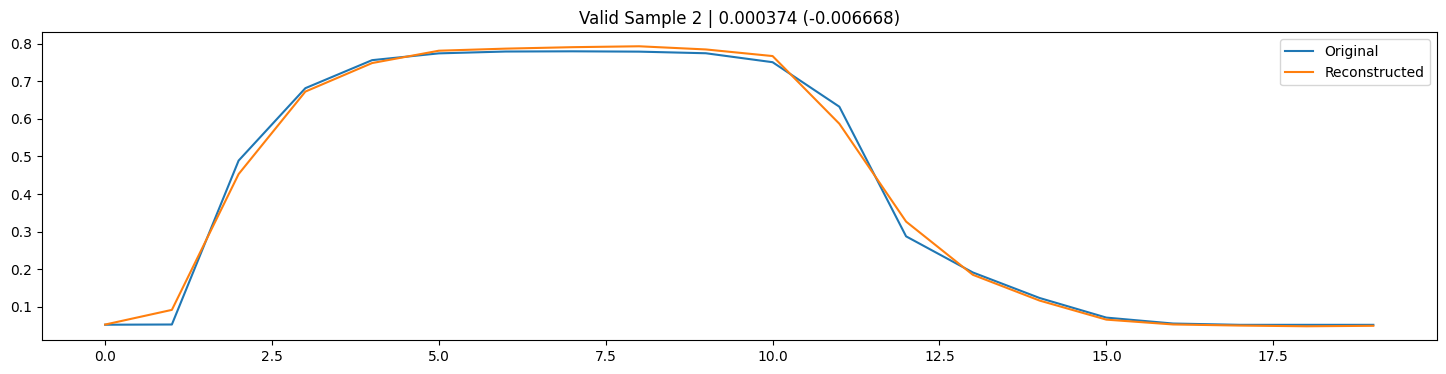

Valid Sample 3 | 0.000404 (-0.006638)


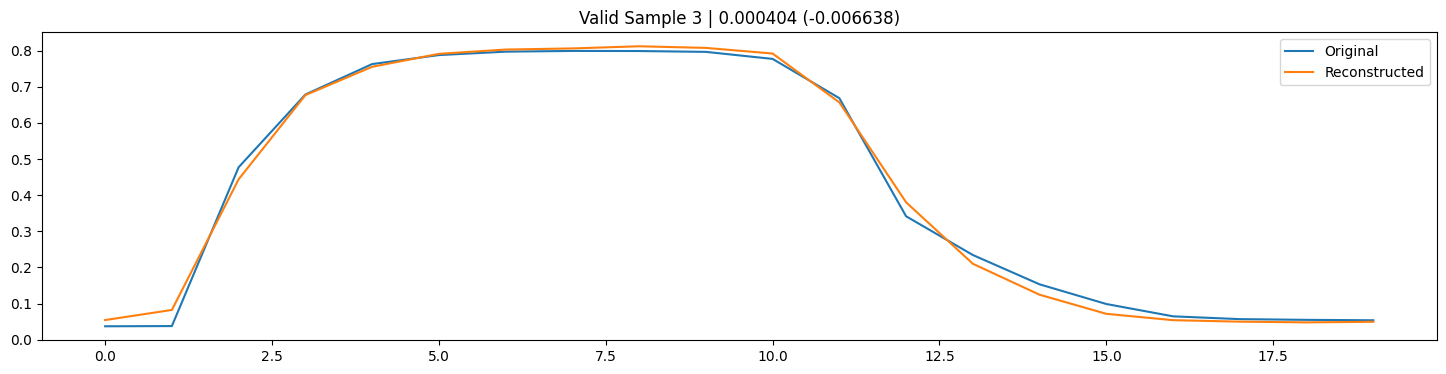


----- WORST VALID SAMPLES -----

Valid Sample 1 | 0.00704 (-2e-06)


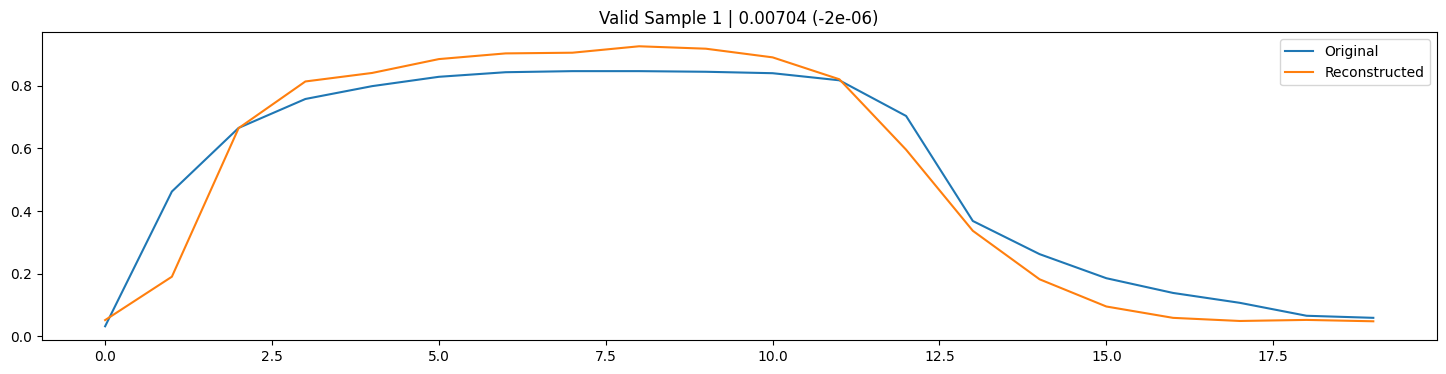

Valid Sample 2 | 0.007037 (-4e-06)


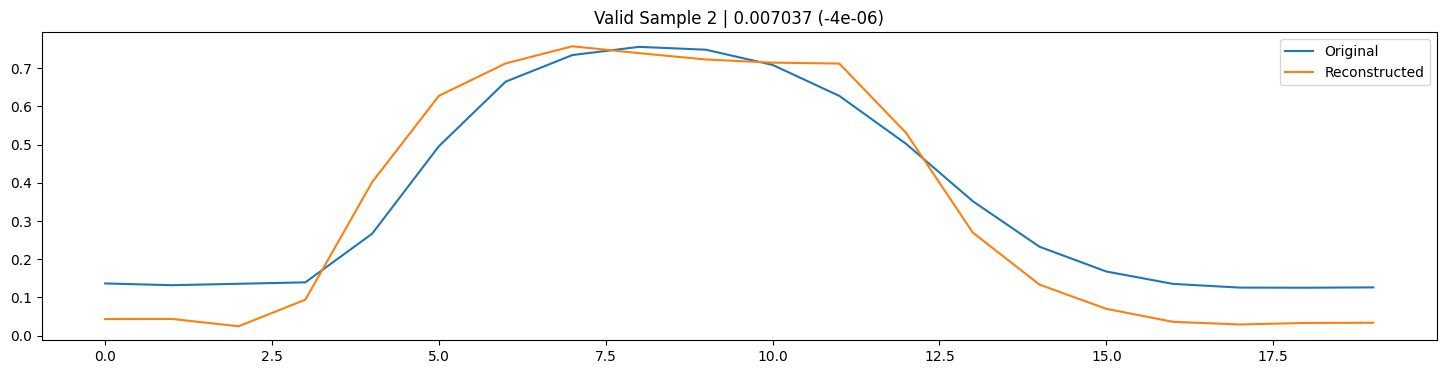

Valid Sample 3 | 0.007033 (-9e-06)


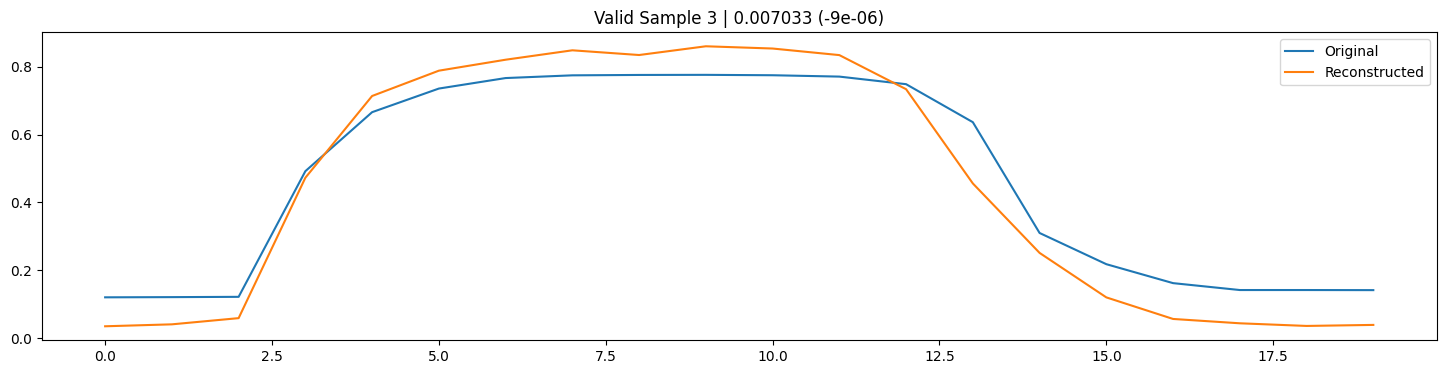

In [35]:
print("----- BEST VALID SAMPLES -----\n")

n_best_valid = 3
best_valid = sorted(valid_predictions, key=lambda x: x[2])
for i in range(n_best_valid):
    original, recon, error, valid = best_valid[i]
    title = f'Valid Sample {i+1} | {round(error, 6)} ({round(error - threshold, 6)})'
    print(title)
    plotting.dual(original, recon, title=title)

print("\n----- WORST VALID SAMPLES -----\n")

n_worst_valid = 3
worst_valid = sorted(valid_predictions, key=lambda x: x[2], reverse=True)
for i in range(n_worst_valid):
    original, recon, error, valid = worst_valid[i]
    title = f'Valid Sample {i+1} | {round(error, 6)} ({round(error - threshold, 6)})'
    print(title)
    plotting.dual(original, recon, title=title)
